In [1]:
%load_ext autoreload
%autoreload 2

import importlib
import sys

sys.path.insert(0, "/home/hey4/rich_tde/dev")

import dev

# isort: split
import matplotlib.pyplot as plt
import numpy as np

import richio

importlib.reload(dev)  # Reapply the repository style when rerunning setup.

<module 'dev' from '/home/hey4/rich_tde/dev/dev/__init__.py'>

$$
H(r) = \frac{\int\int \rho |z| dz d\phi}{\int\int \rho dzd\phi}
= \frac{\int\int \rho |z| dV/rdr}{\int\int \rho dV/rdr}
$$
$$
H(r) \approx \frac{\sum_i \rho_i V_i |z_i| / (r_i \Delta r)}{\sum_i \rho_i V_i / (r_i \Delta r)}
$$

In [2]:
tde = dev.TDEBasics(Mbh=1e4, Mstar=0.5, Rstar=0.47, beta=1)
r_p = tde.r_p * richio.units.lscale
r_a = tde.r_a # this is bad, but for a purpose

In [3]:
tfbs = [0.7, 1.0, 1.5, 2.2]
Hs = {"incoming": [], "outgoing": []}
R_edges = np.logspace(0, 3, 300 + 1)  # adjust range and bin count
for path in dev.SNAPSHOT_TFB("1e4", tfbs):
    snap = richio.load(path)
    R = np.hypot(snap.X, snap.Y)
    w = (snap.density * snap.volume) / R
    abs_z = np.abs(snap.Z)
    vx = snap.vx

    star_mask = snap.mask_star_ratio()
    R = R[star_mask]
    w = w[star_mask]
    abs_z = abs_z[star_mask]
    vx = vx[star_mask]

    for stream, mask in (("incoming", vx > 0), ("outgoing", vx < 0)):
        Htop, _ = np.histogram(R[mask], bins=R_edges, weights=w[mask] * abs_z[mask])
        Hbot, _ = np.histogram(R[mask], bins=R_edges, weights=w[mask])

        H = Htop / Hbot
        Hs[stream].append(H)

/home/hey4/.conda/envs/richanalysis/lib/python3.13/site-packages/unyt/array.py:1972: RuntimeWarning: invalid value encountered in divide
  out_arr = func(


incoming, $t=0.7t_\mathrm{fb}$, max compression 0.2030 code_length
outgoing, $t=0.7t_\mathrm{fb}$, max compression 0.0791 code_length
incoming, $t=1.0t_\mathrm{fb}$, max compression 0.1812 code_length
outgoing, $t=1.0t_\mathrm{fb}$, max compression 0.0793 code_length
incoming, $t=1.5t_\mathrm{fb}$, max compression 0.2257 code_length
outgoing, $t=1.5t_\mathrm{fb}$, max compression 0.1149 code_length
incoming, $t=2.2t_\mathrm{fb}$, max compression 0.9539 code_length
outgoing, $t=2.2t_\mathrm{fb}$, max compression 1.2570 code_length


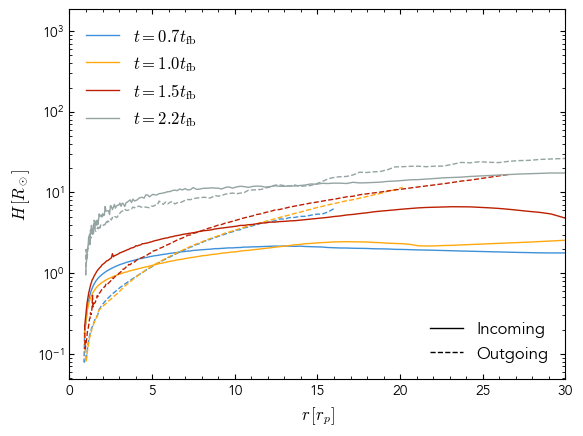

In [4]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots()
labels = [f"$t={t}t_\\mathrm{{fb}}$" for t in tfbs]
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for i, label in enumerate(labels):
    for stream, linestyle in (("incoming", "-"), ("outgoing", "--")):
        H = Hs[stream][i]
        # The minimum H at r > 0.6 r_p, independently for each stream.
        i_left = np.nanargmin(np.where(R_edges[:-1] > 0.6 * r_p, H, np.nan * H.units))
        print(f"{stream}, {label}, max compression {H[i_left]:.4f}")
        r_plot = (R_edges[:-1] / r_p)[i_left:]
        H_plot = H[i_left:]
        if stream == "outgoing":
            ra_t_rp = r_a * tfbs[i]**(2/3) / r_p
            ra_mask = r_plot < ra_t_rp * 0.75
            r_plot = r_plot[ra_mask]
            H_plot = H_plot[ra_mask]
        if stream == "incoming":
            r_start = r_plot[:1]
            H_start = H_plot[:1]
        else:
            # Connect the outgoing curve to the first incoming point.
            r_plot = np.concatenate((r_start, r_plot))
            H_plot = np.concatenate((H_start, H_plot))
        ax.plot(
            r_plot,
            H_plot,
            color=colors[i],
            linestyle=linestyle,
            label=label,
        )
ax.set(yscale="log", xlabel=r"$r\,[r_p]$", ylabel=r"$H\,[R_\odot]$", xlim=(0, 30))
time_legend = ax.legend(handles=ax.lines[::2], loc="upper left")
ax.add_artist(time_legend)
ax.legend(
    handles=[
        Line2D([], [], color="black", linestyle="-", label="Incoming"),
        Line2D([], [], color="black", linestyle="--", label="Outgoing"),
    ],
    loc="lower right",
)
plt.savefig("/home/hey4/rich_tde/reports/shockpaper/figures/compression-1e4.pdf", bbox_inches="tight")
plt.show()

## 1e5 run

In [5]:
tde = dev.TDEBasics(Mbh=1e5, Mstar=0.5, Rstar=0.47, beta=1)
r_p = tde.r_p * richio.units.lscale
r_a = tde.r_a # this is bad, but for a purpose

In [6]:
tfbs = [0.7, 1.0,]
Hs = {"incoming": [], "outgoing": []}
R_edges = np.logspace(0, 4, 300 + 1)  # adjust range and bin count
for path in dev.SNAPSHOT_TFB("1e5", tfbs):
    snap = richio.load(path)
    R = np.hypot(snap.X, snap.Y)
    w = (snap.density * snap.volume) / R
    abs_z = np.abs(snap.Z)
    vx = snap.vx

    star_mask = snap.mask_star_ratio()
    R = R[star_mask]
    w = w[star_mask]
    abs_z = abs_z[star_mask]
    vx = vx[star_mask]

    for stream, mask in (("incoming", vx > 0), ("outgoing", vx < 0)):
        Htop, _ = np.histogram(R[mask], bins=R_edges, weights=w[mask] * abs_z[mask])
        Hbot, _ = np.histogram(R[mask], bins=R_edges, weights=w[mask])

        H = Htop / Hbot
        Hs[stream].append(H)

/home/hey4/.conda/envs/richanalysis/lib/python3.13/site-packages/unyt/array.py:1972: RuntimeWarning: invalid value encountered in divide
  out_arr = func(


incoming, $t=0.7t_\mathrm{fb}$, max compression 0.5344 code_length
outgoing, $t=0.7t_\mathrm{fb}$, max compression 0.5073 code_length
incoming, $t=1.0t_\mathrm{fb}$, max compression 1.3580 code_length
outgoing, $t=1.0t_\mathrm{fb}$, max compression 0.7028 code_length


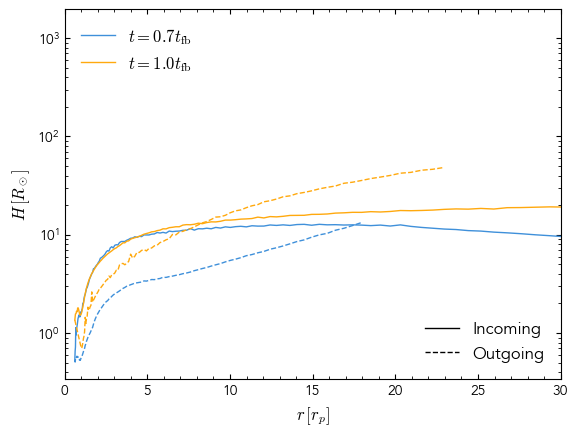

In [7]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots()
labels = [f"$t={t}t_\\mathrm{{fb}}$" for t in tfbs]
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for i, label in enumerate(labels):
    for stream, linestyle in (("incoming", "-"), ("outgoing", "--")):
        H = Hs[stream][i]
        # The minimum H at r > 0.6 r_p, independently for each stream.
        i_left = np.nanargmin(np.where(R_edges[:-1] > 0.6 * r_p, H, np.nan * H.units))
        print(f"{stream}, {label}, max compression {H[i_left]:.4f}")
        r_plot = (R_edges[:-1] / r_p)[i_left:]
        H_plot = H[i_left:]
        if stream == "outgoing":
            ra_t_rp = r_a * tfbs[i]**(2/3) / r_p
            ra_mask = r_plot < ra_t_rp * 0.4
            r_plot = r_plot[ra_mask]
            H_plot = H_plot[ra_mask]
        if stream == "incoming":
            r_start = r_plot[:1]
            H_start = H_plot[:1]
        else:
            # Connect the outgoing curve to the first incoming point.
            r_plot = np.concatenate((r_start, r_plot))
            H_plot = np.concatenate((H_start, H_plot))
        ax.plot(
            r_plot,
            H_plot,
            color=colors[i],
            linestyle=linestyle,
            label=label,
        )
ax.set(yscale="log", xlabel=r"$r\,[r_p]$", ylabel=r"$H\,[R_\odot]$", xlim=(0, 30))
time_legend = ax.legend(handles=ax.lines[::2], loc="upper left")
ax.add_artist(time_legend)
ax.legend(
    handles=[
        Line2D([], [], color="black", linestyle="-", label="Incoming"),
        Line2D([], [], color="black", linestyle="--", label="Outgoing"),
    ],
    loc="lower right",
)
plt.savefig("/home/hey4/rich_tde/reports/shockpaper/figures/compression-1e5.pdf", bbox_inches="tight")
plt.show()

# 1e4 convergence

In [8]:
RUNS = ["1e4", "1e4midres", "1e4lowres"]
TFB = 1.8
R_EDGES = np.logspace(0, 3, 300 + 1) * richio.units.lscale

tde = dev.TDEBasics(Mbh=1e4, Mstar=0.5, Rstar=0.47, beta=1)
r_p = tde.r_p * richio.units.lscale
r_a = tde.r_a * richio.units.lscale
print(f"Target: t / t_fb = {TFB}")

Target: t / t_fb = 1.8


In [9]:
Hs = {"incoming": [], "outgoing": []}
for run in RUNS:
    path = dev.SNAPSHOT_TFB(run, TFB)
    snap = richio.load(path)
    if run == "1e4lowres":
        # The NumPy export contains cell centers of mass.
        R = np.hypot(snap.CMx, snap.CMy)
        abs_z = np.abs(snap.CMz)
        time = snap.tfb
    else:
        R = np.hypot(snap.X, snap.Y)
        abs_z = np.abs(snap.Z)
        time = snap.time
    print(f"{run}: {path.name}, t = {time.squeeze().to('day'):.5f}")
    w = (snap.density * snap.volume) / R
    vx = snap.vx

    star_mask = snap.mask_star_ratio()
    R = R[star_mask]
    w = w[star_mask]
    abs_z = abs_z[star_mask]
    vx = vx[star_mask]

    for stream, mask in (("incoming", vx > 0), ("outgoing", vx < 0)):
        Htop, _ = np.histogram(R[mask], bins=R_EDGES, weights=w[mask] * abs_z[mask])
        Hbot, _ = np.histogram(R[mask], bins=R_EDGES, weights=w[mask])
        # Empty radial bins have undefined height.
        Hbot[Hbot == 0] = np.nan
        H = Htop / Hbot
        Hs[stream].append(H)

1e4: snap_full_127.h5, t = 4.76161 day
1e4midres: snap_full_338.h5, t = 4.79287 day


/tmp/ipykernel_2221818/110610257.py:3: UserWarning: Closest 1e4lowres snapshot is at 1.605 t_fb, which is 0.195 t_fb from the requested 1.800 t_fb
  path = dev.SNAPSHOT_TFB(run, TFB)


1e4lowres: snap_340, t = 4.26209 day


1e4, incoming, max compression 0.6165 code_length
1e4, outgoing, max compression 0.4693 code_length
1e4midres, incoming, max compression 0.5098 code_length
1e4midres, outgoing, max compression 0.4285 code_length
1e4lowres, incoming, max compression 0.4620 code_length
1e4lowres, outgoing, max compression 0.4520 code_length


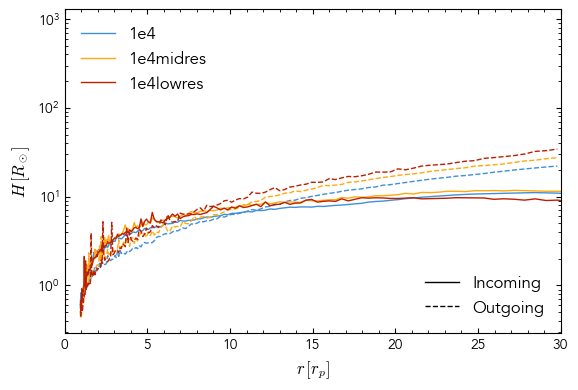

In [10]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(6.4, 4.2))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for i, run in enumerate(RUNS):
    for stream, linestyle in (("incoming", "-"), ("outgoing", "--")):
        H = Hs[stream][i]
        # The minimum H at r > 0.6 r_p, independently for each stream.
        i_left = np.nanargmin(np.where(R_EDGES[:-1] > 0.6 * r_p, H, np.nan * H.units))
        print(f"{run}, {stream}, max compression {H[i_left]:.4f}")
        r_plot = (R_EDGES[:-1] / r_p)[i_left:]
        H_plot = H[i_left:]
        if stream == "outgoing":
            ra_t_rp = r_a * TFB ** (2 / 3) / r_p
            ra_mask = r_plot < ra_t_rp * 0.75
            r_plot = r_plot[ra_mask]
            H_plot = H_plot[ra_mask]
        if stream == "incoming":
            r_start = r_plot[:1]
            H_start = H_plot[:1]
        else:
            # Connect the outgoing curve to the first incoming point.
            r_plot = np.concatenate((r_start, r_plot))
            H_plot = np.concatenate((H_start, H_plot))
        ax.plot(
            r_plot,
            H_plot,
            color=colors[i],
            linestyle=linestyle,
            label=run,
        )
ax.set(yscale="log", xlabel=r"$r\,[r_p]$", ylabel=r"$H\,[R_\odot]$", xlim=(0, 30))
run_legend = ax.legend(handles=ax.lines[::2], loc="upper left")
ax.add_artist(run_legend)
ax.legend(
    handles=[
        Line2D([], [], color="black", linestyle="-", label="Incoming"),
        Line2D([], [], color="black", linestyle="--", label="Outgoing"),
    ],
    loc="lower right",
)
# plt.savefig("/home/hey4/rich_tde/reports/shockpaper/figures/")
plt.show()